In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
# ==========================================================
# Load Processed Data
# ==========================================================
from pathlib import Path
DOWNLOADS_DIR = Path.home() / "Downloads"

X_train = pd.read_csv(DOWNLOADS_DIR/"X_train.csv")
X_test = pd.read_csv(DOWNLOADS_DIR/"X_test.csv")

y_train = pd.read_csv(DOWNLOADS_DIR/"y_train.csv").squeeze()
y_test = pd.read_csv(DOWNLOADS_DIR/"y_test.csv").squeeze()

In [3]:
# ==========================================================
# Define Machine Learning Models
# ==========================================================

models = {

    "Logistic Regression":
        LogisticRegression(random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )

}

In [4]:
# ==========================================================
# Train Models
# ==========================================================

results = []

predictions = {}

probabilities = {}

In [5]:
import time

In [6]:
# ==========================================================
# Train and Evaluate Models
# ==========================================================

for name, model in models.items():

    print("="*60)
    print(name)
    print("="*60)

    # Train model
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    training_time = end - start

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    # Store
    predictions[name] = y_pred
    probabilities[name] = y_prob

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    # Save results

    results.append({

        "Model":name,

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1 Score":f1,

        "ROC-AUC":roc_auc,
        "Training Time (s)": training_time

    })

    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1 Score : {f1:.3f}")
    print(f"ROC AUC  : {roc_auc:.3f}")

Logistic Regression
Accuracy : 0.870
Precision: 0.779
Recall   : 0.568
F1 Score : 0.657
ROC AUC  : 0.867
Decision Tree
Accuracy : 0.886
Precision: 0.728
Recall   : 0.762
F1 Score : 0.745
ROC AUC  : 0.841
Random Forest
Accuracy : 0.934
Precision: 0.960
Recall   : 0.728
F1 Score : 0.828
ROC AUC  : 0.929


In [7]:
# ==========================================================
# Model Performance Comparison
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
2,Random Forest,0.933981,0.960037,0.728491,0.828388,0.928582,2.567611
0,Logistic Regression,0.870122,0.778530,0.567701,0.656607,0.866827,0.049926
1,Decision Tree,0.885701,0.728254,0.761636,0.744571,0.841035,0.103041


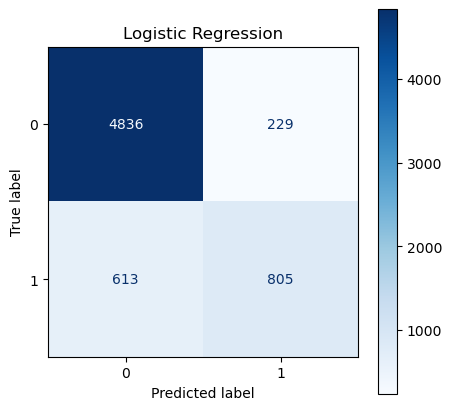

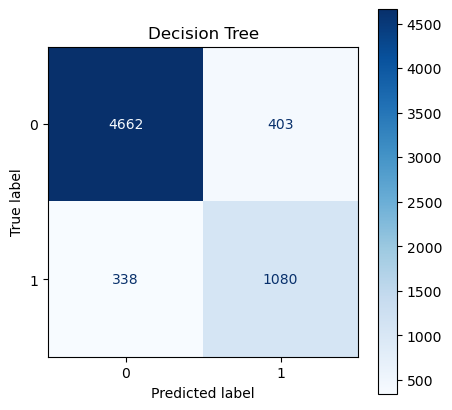

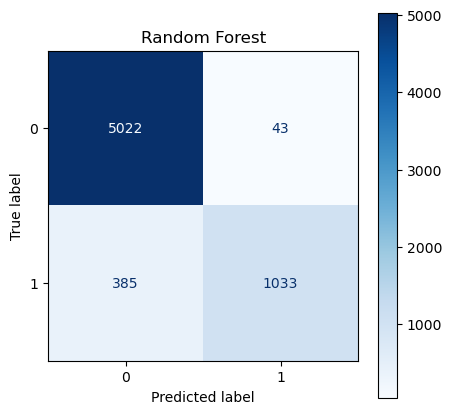

In [8]:
# ==========================================================
# Confusion Matrices
# ==========================================================

for name in models.keys():

    fig, ax = plt.subplots(figsize=(5,5))

    ConfusionMatrixDisplay.from_predictions(

        y_test,

        predictions[name],

        cmap="Blues",

        ax=ax

    )

    plt.title(name)

    plt.show()

<Figure size 800x600 with 0 Axes>

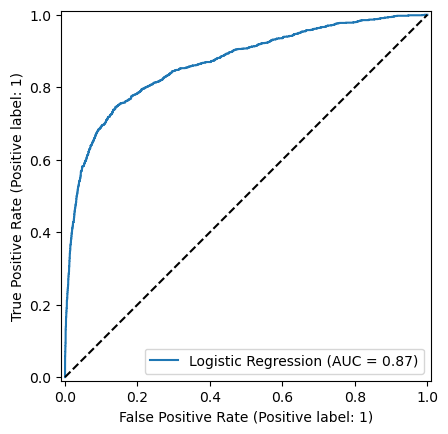

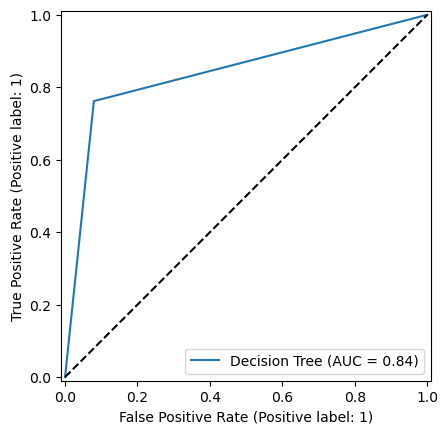

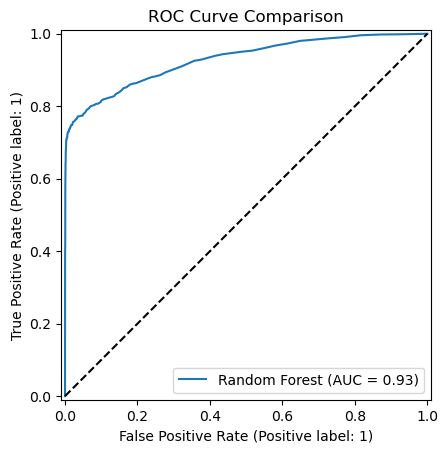

In [9]:
# ==========================================================
# ROC Curve Comparison
# ==========================================================

plt.figure(figsize=(8,6))

for name in models.keys():

    RocCurveDisplay.from_predictions(

        y_test,

        probabilities[name],

        name=name

    )

    plt.plot(
    
        [0,1],
    
        [0,1],
    
        "--",
    
        color="black"
    
    )

plt.title("ROC Curve Comparison")

plt.show()

In [10]:
# ==========================================================
# Random Forest Feature Importance
# ==========================================================

rf = models["Random Forest"]

importance = pd.Series(

    rf.feature_importances_,

    index=X_train.columns

)

importance = importance.sort_values(
    ascending=False
)

importance

loan_percent_income            0.218342
person_income                  0.152417
loan_int_rate                  0.121611
loan_amnt                      0.081736
person_home_ownership_RENT     0.076058
person_emp_length              0.059889
loan_grade_D                   0.054117
person_age                     0.049344
cb_person_cred_hist_length     0.037738
loan_grade_C                   0.017340
person_home_ownership_OWN      0.017209
loan_intent_HOMEIMPROVEMENT    0.015822
loan_grade_E                   0.015640
loan_intent_MEDICAL            0.015513
loan_intent_EDUCATION          0.015150
cb_person_default_on_file_Y    0.013836
loan_intent_PERSONAL           0.012760
loan_intent_VENTURE            0.012167
loan_grade_F                   0.004908
loan_grade_B                   0.004748
loan_grade_G                   0.002571
person_home_ownership_OTHER    0.001086
dtype: float64

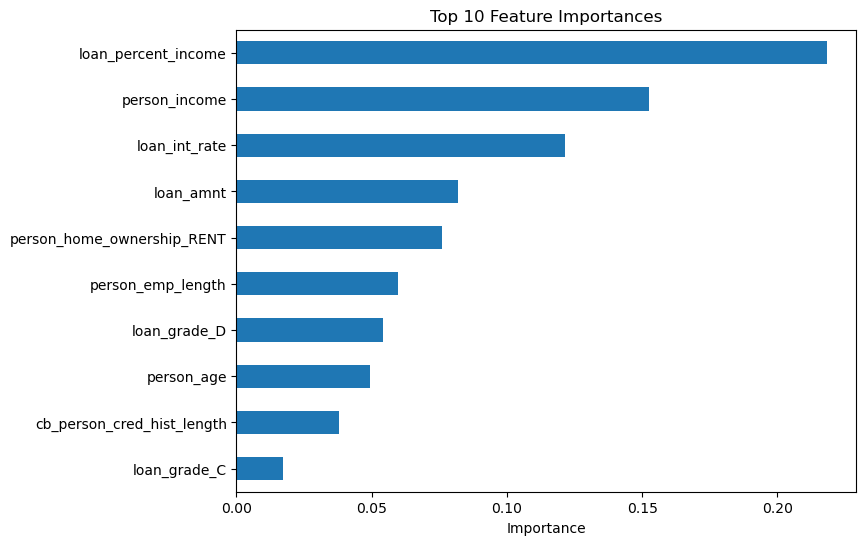

In [11]:
# ==========================================================
# Top 10 Important Features
# ==========================================================

plt.figure(figsize=(8,6))

importance.head(10).sort_values().plot.barh()

plt.xlabel("Importance")

plt.title("Top 10 Feature Importances")

plt.show()

In [12]:
# ==========================================================
# Best Model
# ==========================================================

best_model = results_df.iloc[0]

best_model

Model                Random Forest
Accuracy                  0.933981
Precision                 0.960037
Recall                    0.728491
F1 Score                  0.828388
ROC-AUC                   0.928582
Training Time (s)         2.567611
Name: 2, dtype: object

In [13]:
# ==========================================================
# Individual Prediction
# ==========================================================

sample = X_test.sample(1, random_state=42)

In [14]:
sample

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
3558,-0.274335,1.711657,-0.18676,1.336049,-1.307867,-0.469895,-0.44344,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [15]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 3558 to 3558
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   1 non-null      float64
 1   person_income                1 non-null      float64
 2   person_emp_length            1 non-null      float64
 3   loan_amnt                    1 non-null      float64
 4   loan_int_rate                1 non-null      float64
 5   loan_percent_income          1 non-null      float64
 6   cb_person_cred_hist_length   1 non-null      float64
 7   person_home_ownership_OTHER  1 non-null      int64  
 8   person_home_ownership_OWN    1 non-null      int64  
 9   person_home_ownership_RENT   1 non-null      int64  
 10  loan_intent_EDUCATION        1 non-null      int64  
 11  loan_intent_HOMEIMPROVEMENT  1 non-null      int64  
 12  loan_intent_MEDICAL          1 non-null      int64  
 13  loan_intent_PERSONAL   

In [16]:
prediction = rf.predict(sample)[0]

probability = rf.predict_proba(sample)[0][1]

label = "Default" if prediction == 1 else "Non-Default"

print(f"Predicted Class: {label}")
print(f"Probability of Default: {probability:.2%}")

Predicted Class: Non-Default
Probability of Default: 1.00%


Predicted default probability for applicant 3558: 1.00%


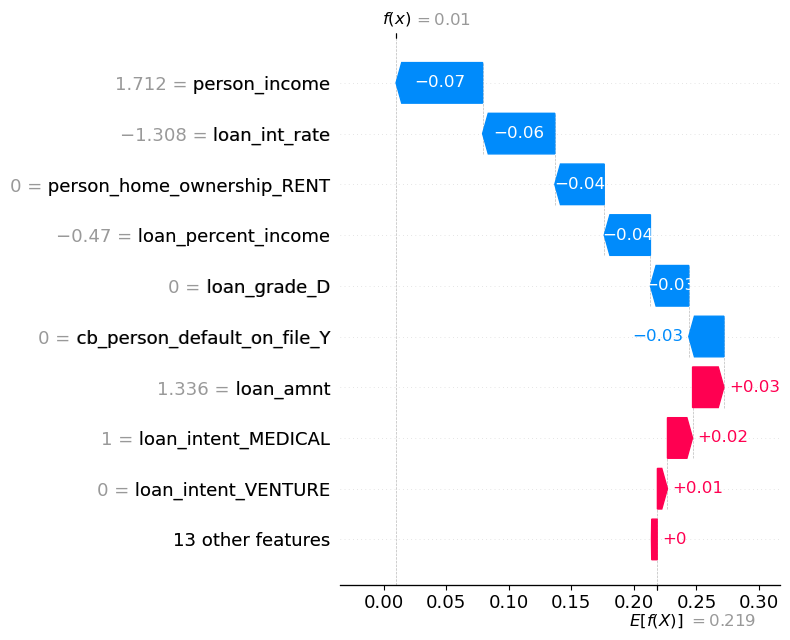

In [17]:
##Shapley Additive Explanations
import shap

explainer = shap.TreeExplainer(rf)
X_sample = X_test.sample(n=min(100, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Handle both old (list) and new (3D array) SHAP output formats
if isinstance(shap_values, list):
    shap_values_default = shap_values[1]
elif np.array(shap_values).ndim == 3:
    shap_values_default = shap_values[:, :, 1]
else:
    shap_values_default = shap_values

base_value = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, tuple, np.ndarray))
    else explainer.expected_value
)

applicant_label = 3558
if applicant_label not in X_sample.index:
    print(f"Applicant {applicant_label} wasn't included in this sample.")
else:
    pos = X_sample.index.get_loc(applicant_label)

    single_prediction = model.predict_proba(X_sample.loc[[applicant_label]])[0][1]
    print(f"Predicted default probability for applicant {applicant_label}: {single_prediction:.2%}")

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values_default[pos],
            base_values=base_value,
            data=X_sample.loc[applicant_label],
            feature_names=X_sample.columns.tolist()
        ),
        show=False
    )
    plt.tight_layout()
    plt.show()

In [18]:
y_test.iloc[3558]

np.int64(0)

In [19]:
pred = rf.predict(X_test)

false_positive = X_test[(pred == 1) & (y_test == 0)]

false_negative = X_test[(pred == 0) & (y_test == 1)]

In [20]:
false_positive.head()

false_negative.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,0.373254,0.810298,-1.161998,-0.737568,-0.006867,-1.124844,0.792241,0,0,0,...,0,0,0,1,0,0,0,0,0,0
21,0.049460,-0.474619,1.519908,-0.884268,2.481296,-0.657024,-0.196304,0,0,1,...,0,0,1,0,0,0,1,0,0,1
22,1.506535,0.234962,-1.161998,-0.630517,-0.088179,-0.937716,1.533650,0,0,0,...,0,1,0,1,0,0,0,0,0,0
43,-0.274335,-0.570508,-0.186760,-0.408486,0.965631,0.185053,-0.937713,0,0,1,...,1,0,0,0,1,0,0,0,0,1
51,-0.921924,-0.694129,-0.186760,-0.602763,-1.818510,0.278617,-0.690576,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
print("False Positives:", len(false_positive))
print("False Negatives:", len(false_negative))

False Positives: 43
False Negatives: 385
